In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
import pandas as pd
import os
from tp7.tp7 import Tape7
import scipy.integrate as integrate
# from srfs.srfs import SRFS

get all tape7 files loaded -> get all data frames -> calculate all unfiltered radiances (y) -> do srf conversion

In [3]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

In [4]:
a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

In [5]:
land = Tape7(a00_files[1])

In [39]:
land2 = Tape7(a41_files[1])

In [42]:
land2.build_scene_description()
land2._compute_radiences()

array([[[1.00000000e+03, 5.00000000e+02, 3.33333333e+02, ...,
         2.50125063e-01, 2.50062516e-01, 2.50000000e-01],
        [9.69352280e-25, 1.80776000e-22, 3.70215000e-21, ...,
         1.51157529e-02, 1.48277833e-02, 1.57356800e-02],
        [2.13490000e-06, 3.15152000e-05, 1.49130000e-04, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[1.00000000e+03, 5.00000000e+02, 3.33333333e+02, ...,
         2.50125063e-01, 2.50062516e-01, 2.50000000e-01],
        [9.28962602e-25, 1.76540000e-22, 3.67299000e-21, ...,
         1.51157529e-02, 1.48277833e-02, 1.57356800e-02],
        [2.13410000e-06, 3.14864000e-05, 1.49049000e-04, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[1.00000000e+03, 5.00000000e+02, 3.33333333e+02, ...,
         2.50125063e-01, 2.50062516e-01, 2.50000000e-01],
        [9.28962602e-25, 1.73832000e-22, 3.63078000e-21, ...,
         1.51157529e-02, 1.48277833e-02, 1.57356800e-02],
        [2.13200000e-06, 3.14020000e

In [55]:
sw2 =  land2.rads[629, 1, :]
wavelength2 = land2.rads[629, 0, :]

In [56]:
interp_vals = np.interp(x=wavelength2, xp=tot_wvln, fp=sw_vals)
interp_vals.shape

(4000,)

In [57]:
check = sw2 * interp_vals

In [4]:
a00_data = [Tape7(file) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

KeyboardInterrupt: 

In [ ]:
land = a00["Land"]

In [7]:
class SRFS:
    def __init__(self, file_path):
        self.file_path = file_path
        self.srf_vals = None
        self.conversion_df = {}
        self.process_srf()
        
        
    def process_srf(self):
        srf = pd.read_csv(self.file_path)
        
        # loop through and create a column in the dataframe that holds the end of the wavelength range
        for index, row in srf.iterrows():
            next_index = index + 1
            if next_index not in srf.index:
                continue
            else:
                srf.loc[index, 'End_wv_range'] = srf.loc[next_index, 'wavelength [um]']
               
        # create the first row in the dataframe starting at wavelenght 0.0 and ending at the first wavelength from the csv 
        new_row = srf.iloc[0].copy()
        new_row.loc['End_wv_range'] = new_row['wavelength [um]']
        new_row.loc['wavelength [um]'] = 0.0
        data, cols = new_row.values, new_row.index
        tdf = pd.DataFrame([data], columns=cols)
        srf = pd.concat([tdf, srf])
    
        # add the final end value to replace the NAN
        srf.loc[999, 'End_wv_range'] = 1001

        self.srf_vals = srf

        return
    
    def create_conversion_df(self, wavelength_arr: np.array or pd.DataFrame or pd.Series, wv_name: str, rads):
        bins = pd.IntervalIndex.from_arrays(self.srf_vals['wavelength [um]'], self.srf_vals['End_wv_range'], closed='left')
        binned_data = pd.cut(wavelength_arr, bins)
        interval_and_srf = dict(zip(bins, self.srf_vals[wv_name]))
        nm = None
        if wv_name == " sw srf":
            nm = "Shortwave rads"
        else:
            nm = "Longwave rads"
        df = pd.DataFrame({
            "Wavelength" : wavelength_arr,
            "Range": binned_data,
        })
        print(type(interval_and_srf))
        df[wv_name] = df["Range"].map(interval_and_srf)
        df[nm] = rads
        self.conversion_df = df
        return df


In [8]:
srf = SRFS("./data/libera_srfs_20241017.csv")
srf.srf_vals.columns

Index(['wavelength [um]', ' ssw srf', ' conv ssw srf', ' lw srf',
       ' conv lw srf', ' total srf', ' conv total srf', ' sw srf',
       ' conv sw srf', 'End_wv_range'],
      dtype='object')

In [9]:
srf.srf_vals

,wavelength [um],ssw srf,conv ssw srf,lw srf,conv lw srf,total srf,conv total srf,sw srf,conv sw srf,End_wv_range
0,0.000000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.300000
0,0.300000,0.0,0.0,0.00000,0.00000,0.00860,0.00865,0.01079,0.01076,0.301750
1,0.301750,0.0,0.0,0.00000,0.00000,0.00965,0.00965,0.01006,0.01006,0.303509
2,0.303509,0.0,0.0,0.00000,0.00000,0.01077,0.01076,0.00933,0.00933,0.305279
3,0.305279,0.0,0.0,0.00000,0.00000,0.01182,0.01178,0.00863,0.00865,0.307060
...,...,...,...,...,...,...,...,...,...,...
995,97.700859,0.0,0.0,0.44098,0.45646,0.89716,0.89719,-0.00000,-0.00000,98.270641
996,98.270641,0.0,0.0,0.50463,0.49343,0.89582,0.89590,-0.00000,-0.00000,98.843745
997,98.843745,0.0,0.0,0.56496,0.52561,0.89447,0.89473,-0.00000,-0.00000,99.420192
998,99.420192,0.0,0.0,0.57120,0.54465,0.89312,0.89376,-0.00000,-0.00000,100.000000


In [67]:
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']

In [11]:
sw_srf.shape

(1001,)

In [12]:
land.build_scene_description()

,Scene,SZA,VZA,RAZ,Cld Type,Run #
0,Land,0.0,0.000,0.0,0,0
1,Land,0.0,0.000,0.0,1,1
2,Land,0.0,0.000,0.0,1,2
3,Land,0.0,0.000,0.0,1,3
4,Land,0.0,0.000,0.0,1,4
...,...,...,...,...,...,...
625,Land,0.0,79.914,172.5,0,625
626,Land,0.0,79.914,172.5,1,626
627,Land,0.0,79.914,172.5,1,627
628,Land,0.0,79.914,172.5,1,628


In [13]:
(one, two) = land.integrate_radiances(sw_srf=sw_srf, lw_srf=lw_srf)


In [14]:
land.rads.shape

(630, 3, 4000)

In [15]:
test = pd.Series(land.rads[-1][0])
t2 = pd.Series(land.rads[-1][1])

In [16]:
test

0       1000.000000
1        500.000000
2        333.333333
3        250.000000
4        200.000000
           ...     
3995       0.250250
3996       0.250188
3997       0.250125
3998       0.250063
3999       0.250000
Length: 4000, dtype: float64

In [17]:
t2

0       5.167800e-24
1       7.998000e-22
2       1.390230e-20
3       1.049504e-14
4       2.514500e-14
            ...     
3995    3.067616e-02
3996    8.330211e-03
3997    3.295902e-02
3998    3.232943e-02
3999    3.430720e-02
Length: 4000, dtype: float64

In [18]:
one.shape

(630,)

In [19]:
sw_run_629 =  land.rads[629, 1, :]
wavelength_run_629 = land.rads[629, 0, :]
sw_run_629

array([5.16780000e-24, 7.99800000e-22, 1.39023000e-20, ...,
       3.29590162e-02, 3.23294292e-02, 3.43072000e-02])

In [ ]:
# srf = SRFS("./data/libera_srfs_20241017.csv")
srf_df = srf.create_conversion_df(wavelength_run_629, " sw srf", sw_run_629)
srf_df

<class 'dict'>


,Wavelength,Range,sw srf,Shortwave rads
0,1000.000000,"[100.0, 1001.0)",-0.00000,5.167800e-24
1,500.000000,"[100.0, 1001.0)",-0.00000,7.998000e-22
2,333.333333,"[100.0, 1001.0)",-0.00000,1.390230e-20
3,250.000000,"[100.0, 1001.0)",-0.00000,1.049504e-14
4,200.000000,"[100.0, 1001.0)",-0.00000,2.514500e-14
...,...,...,...,...
3995,0.250250,"[0.0, 0.3)",0.01079,3.067616e-02
3996,0.250188,"[0.0, 0.3)",0.01079,8.330211e-03
3997,0.250125,"[0.0, 0.3)",0.01079,3.295902e-02
3998,0.250063,"[0.0, 0.3)",0.01079,3.232943e-02


In [33]:
sw_vals = srf.srf_vals[" sw srf"]
sw_vals

0      0.01079
0      0.01079
1      0.01006
2      0.00933
3      0.00863
        ...   
995   -0.00000
996   -0.00000
997   -0.00000
998   -0.00000
999   -0.00000
Name:  sw srf, Length: 1001, dtype: float64

In [34]:
tot_wvln = srf.srf_vals['wavelength [um]']
tot_wvln

0        0.000000
0        0.300000
1        0.301750
2        0.303509
3        0.305279
          ...    
995     97.700859
996     98.270641
997     98.843745
998     99.420192
999    100.000000
Name: wavelength [um], Length: 1001, dtype: float64

In [35]:
interp_vals = np.interp(x=wavelength_run_629, xp=tot_wvln, fp=sw_vals)
interp_vals.shape

(4000,)

In [36]:
sw_run_629.shape

(4000,)

In [37]:
check = sw_run_629 * interp_vals

In [31]:
check

array([5.57605620e-26, 8.62984200e-24, 1.50005817e-22, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [23]:
interp_vals

array([0.01079, 0.01079, 0.01079, ..., 0.     , 0.     , 0.     ])

In [43]:
t3 = pd.Series(interp_vals)

In [45]:
for i in t3:
    print(i)

0.01079
0.01079
0.01079
0.01079
0.01079
0.01079
0.01079
0.01079
0.01079
0.01079
0.005259851213169189
0.3645312023349978
0.6286026892941251
0.7018535416289845
0.7260264412889619
0.7398378156462323
0.7508092902079501
0.761173684054832
0.7645618000283261
0.7700202309452112
0.7720592344032794
0.7742893696414643
0.7730533508002372
0.7702710657253944
0.7677710501504083
0.762909873730992
0.7603743674875109
0.7611383198051948
0.7648405636636265
0.7657509508566801
0.7718487639296344
0.7740223499191585
0.779317090271444
0.7895652840753103
0.7906265196365995
0.7973113614783867
0.8027883734346923
0.8039615533736266
0.8109062650417522
0.813143058159543
0.8137397786869429
0.8208689528589077
0.8226845044636375
0.8215377232451572
0.8270311303113008
0.8337346519943105
0.8308719091514299
0.8302936148911326
0.8327652181918197
0.8376813682330924
0.8377703672921438
0.8353099065698251
0.83672480955767
0.8407351870787895
0.8411552505724786
0.8388226868803202
0.837081272291796
0.8368519585419042
0.84025147552

In [46]:
def is_strictly_increasing(arr):
    return np.all(np.diff(arr) > 0)

In [63]:
is_strictly_increasing(wavelength_run_629[::-1]), is_strictly_increasing(tot_wvln), is_strictly_increasing(np.sort(sw_vals))

(np.True_, np.True_, np.False_)

In [61]:
sw_vals = np.sort(sw_vals)

In [32]:
for i in check:
    print(i)

5.5760562e-26
8.629842e-24
1.5000581699999999e-22
1.1324148159999998e-16
2.7131455e-16
8.9011026e-16
2.2798503909999996e-15
5.074027711999999e-15
1.042495272e-14
2.0237724e-14
1.7203663615324338e-14
1.9910927571507075e-12
5.363322377817841e-12
8.836378200321411e-12
1.3210432263134338e-11
1.9151974379045633e-11
2.650458153688242e-11
3.448984526768211e-11
4.393476398559173e-11
5.499484489410698e-11
9.078168176800536e-11
1.3518200412586138e-10
1.8829064882943627e-10
2.4950127387494907e-10
4.826880620914348e-10
6.197492255974723e-10
7.871797690271114e-10
9.913516071028181e-10
1.2542359592887601e-09
1.572768220455027e-09
1.9740845666097582e-09
2.445167564288619e-09
3.031726386877004e-09
3.6477552924248665e-09
4.2537288009488316e-09
5.090938925988303e-09
6.13581349228478e-09
7.491419877260498e-09
9.856870309066274e-09
1.1968294890104724e-08
1.4745925002746257e-08
1.941930010125899e-08
2.488134666265717e-08
2.916176308543512e-08
3.8262739974300133e-08
5.4170988570274526e-08
9.243054494280902e

In [66]:
def plot_radiance(rads, title, runnum):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]
    # print('')
    # print(describer_df)
    # print(np.shape(rads))
    print(np.shape(rads), print(runnum))
    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    # ax.plot(rads[:,0,runnum], rads[:,1, runnum], 'r-', label='SW Radiance')
    ax.plot(rads[runnum, 0, :], rads[runnum, 1, :], 'r-', label='SW Radiance')
    #ax.plot(rads[:,0,runnum], rads[:,2, runnum], 'b-', label='LW Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    plt.xlim(0,5)

In [27]:
def plot_radiance1(rads, title, runnum, extra):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]
    # print('')
    # print(describer_df)
    # print(np.shape(rads))
    print(np.shape(rads), print(runnum))
    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    # ax.plot(rads[:,0,runnum], rads[:,1, runnum], 'r-', label='SW Radiance')
    ax.plot(rads[runnum, 0, :], extra, 'r-', label='SW Radiance')
    #ax.plot(rads[:,0,runnum], rads[:,2, runnum], 'b-', label='LW Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    plt.xlim(0,5)

629
(630, 3, 4000) None


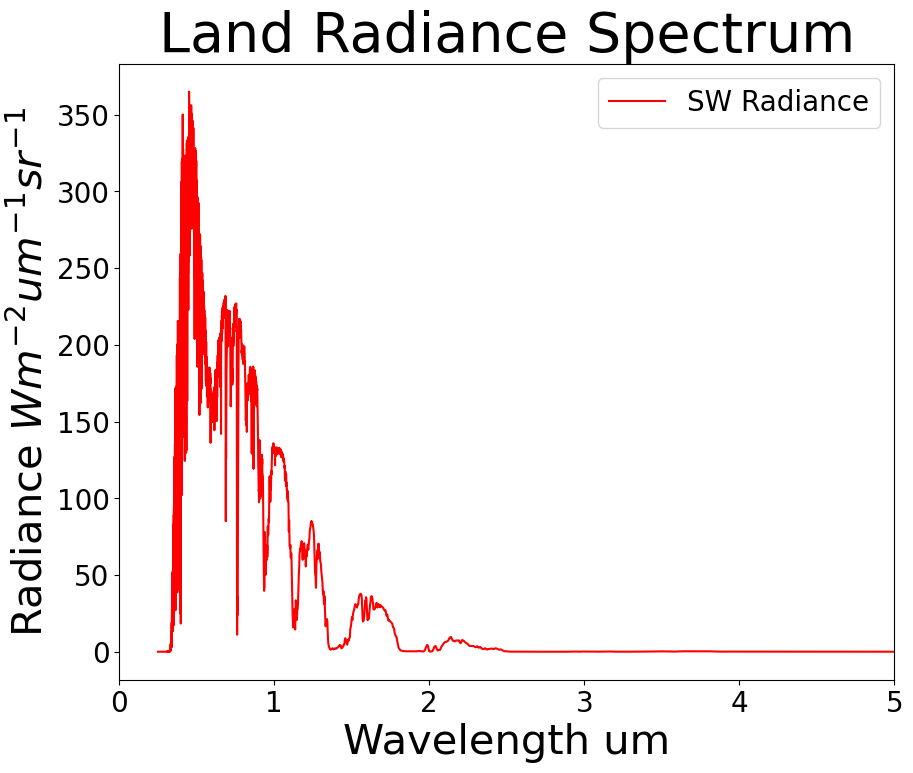

In [58]:
plot_radiance1(land2.rads, land2.title, 629, check)

0
(630, 3, 4000) None


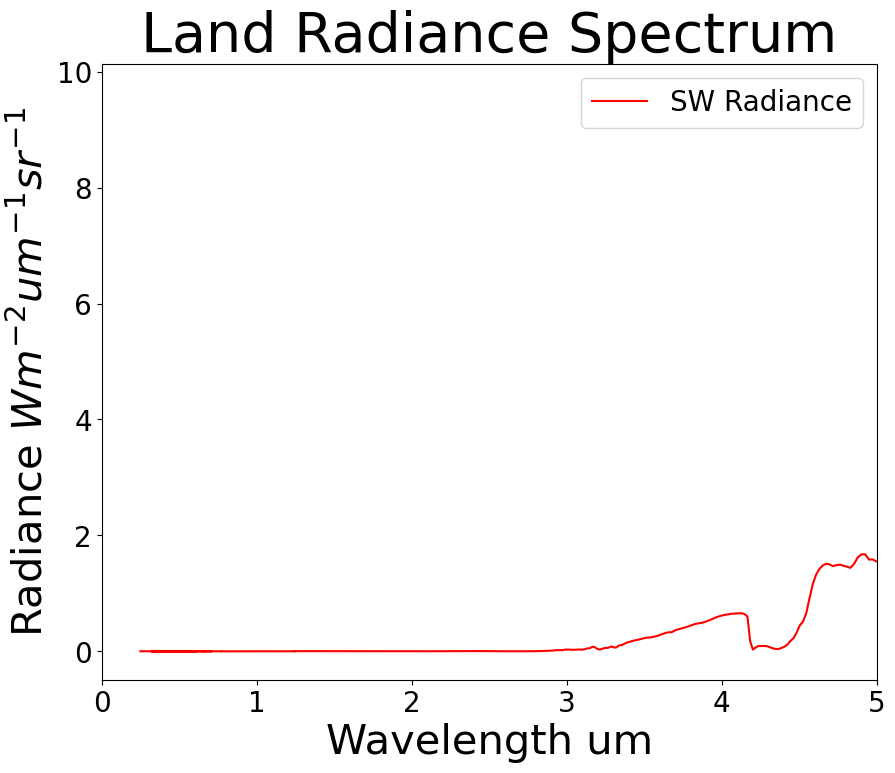

In [64]:
plot_radiance(land.rads, land.title, 0)

629
(630, 3, 4000) None


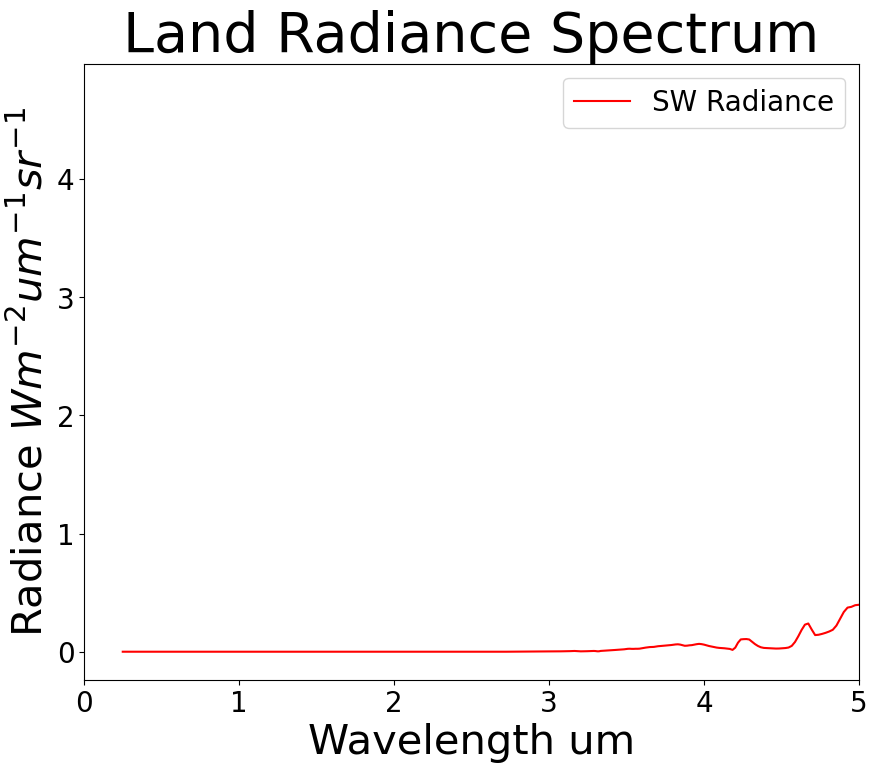

In [65]:
plot_radiance(land.rads, land2.title, 629)

In [68]:
(one, two) = land.integrate_radiances(sw_srf=sw_srf, lw_srf=lw_srf)

In [78]:
sw_629 = land.rads[629, 1, :]
wv_629 = land.rads[629, 0, :]
sw_629.shape

(4000,)

In [81]:
-integrate.simpson(y=sw_629, x=wv_629)

np.float64(235.48130214412734)

In [75]:
sun_value = one[0] * 6.79e-5

In [76]:
sun_value

np.float64(0.006921971132370555)

check toa values (energry from sun)

integrate R dTheta * pi r^2 / (1 AU)^2 should be around 1300 watts per meter squared

R is radiance